1\. **PCA on 3D dataset**

* Generate a dataset with 3 features each with N entries (N being ${\cal O}(1000)$). With $N(\mu,\sigma)$ the normali distribution with mean $\mu$ and $\sigma$  standard deviation, generate the 3 variables $x_{1,2,3}$ such that:
    * $x_1$ is distributed as $N(0,1)$
    * $x_2$ is distributed as $x_1+N(0,3)$
    * $x_3$ is given by $2x_1+x_2$
* Find the eigenvectors and eigenvalues of the covariance matrix of the dataset
* Find the eigenvectors and eigenvalues using SVD. Check that the two procedures yield to same result
* What percent of the total dataset's variability is explained by the principal components? Given how the dataset was constructed, do these make sense? Reduce the dimensionality of the system so that at least 99% of the total variability is retained.
* Redefine the data in the basis yielded by the PCA procedure
* Plot the data points in the original and the new coordiantes as a set of scatter plots. Your final figure should have 2 rows of 3 plots each, where the columns show the (0,1), (0,2) and (1,2) proejctions.


,x1,x2,x3
0,-1.085631,-3.332113,-5.503374
1,0.997345,2.700130,4.694821
2,0.282978,2.437430,3.003387
3,-1.506295,-4.504437,-7.517026
4,-0.578600,0.846095,-0.311106
...,...,...,...
995,0.634763,3.171867,4.441393
996,1.069919,-2.289849,-0.150012
997,-0.909327,-1.987217,-3.805871
998,0.470264,-4.358822,-3.418294


cov: [[ 1.00257827  0.9125078   2.91766434]
 [ 0.9125078   9.0907464  10.91576199]
 [ 2.91766434 10.91576199 16.75109067]]
eigenvalues:  [ 2.48444042e+01+0.j -4.04395246e-16+0.j  2.00001118e+00+0.j]
eigenvectors:  [[-0.12126076 -0.81649658  0.56447246]
 [-0.57007399 -0.40824829 -0.71298596]
 [-0.81259551  0.40824829  0.41595897]]
means:  [-0.03956413608079184, -0.014396633893171, -0.09352490605475468]


,x1,x2,x3
0,-1.046066,-3.317716,-5.409849
1,1.036910,2.714526,4.788345
2,0.322543,2.451827,3.096912
3,-1.466731,-4.490040,-7.423501
4,-0.539036,0.860491,-0.217581
...,...,...,...
995,0.674327,3.186263,4.534918
996,1.109483,-2.275452,-0.056487
997,-0.869763,-1.972821,-3.712346
998,0.509828,-4.344425,-3.324769


eigenvalues with svd:  [2.48444042e+01 2.00001118e+00 5.86419430e-31] 

the columns are eigenvectors with svd:  [[-0.12126076  0.56447246 -0.81649658]
 [-0.57007399 -0.71298596 -0.40824829]
 [-0.81259551  0.41595897  0.40824829]] 

[[2.48444042e+01 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 2.00001118e+00 0.00000000e+00]
 [0.00000000e+00 0.00000000e+00 5.86419430e-31]]
Lambda.trace(): 26.844415342696706
x1 explains the  0.9254961914750407  of the total
x2 explains the  0.07450380852495926  of the total
x3 explains the  2.1845118349387205e-32  of the total
after reduction x1 explains still the  0.9254961914750407  of the total
[[ 6.41420991e+00 -5.56420528e+00 -3.95337126e+00 ...  4.24675773e+00
   5.11651398e+00  3.33250931e+00]
 [-4.75265879e-01  6.41643033e-01 -2.77863277e-01 ... -6.28547600e-01
   2.00233019e+00 -1.18298721e+00]
 [-4.27796876e-16 -5.68862839e-16  3.10345094e-16 ...  4.14518057e-16
  -1.95150724e-15  7.28648965e-16]]


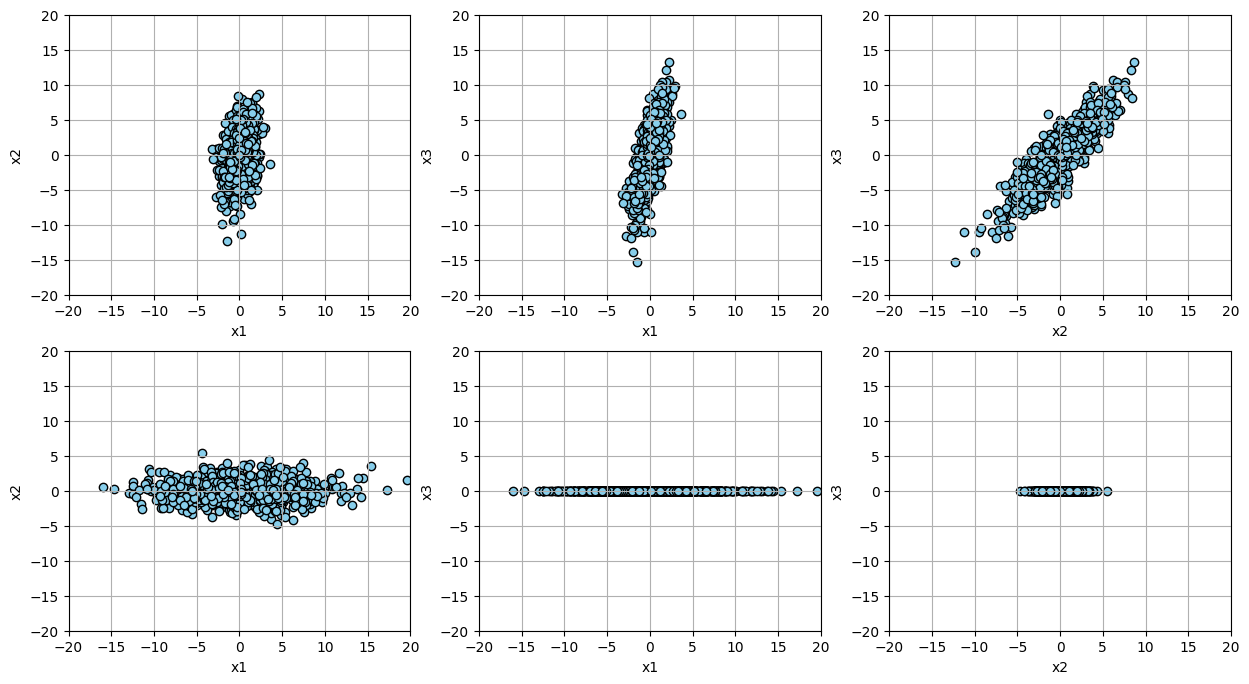

In [110]:
import numpy as np
import numpy.random as npr
import pandas as pd
from scipy import linalg as la
import matplotlib.pyplot as plt

npr.seed(123)

df = pd.DataFrame({ })
df['x1'] = npr.normal(0, 1, 1000)
df['x2'] = df['x1'] + npr.normal(0, 3, 1000)
df['x3'] = 2*df['x1'] + df['x2']
display(df)

v = np.cov(df.T)
print('cov:', v)

l, V = la.eig(v)

print ('eigenvalues: ', l)
print ('eigenvectors: ', V)

means = [df['x1'].mean(), df['x2'].mean(), df['x3'].mean()]
print('means: ', means)
df0 =pd.DataFrame({
    'x1' : df['x1']-means[0],
    'x2' : df['x2']-means[1],
    'x3' : df['x3']-means[2]
})
display(df0)

U, spectrum, Vt = la.svd(df0.T)

print ('eigenvalues with svd: ', spectrum**2/(999),'\n')
print ('the columns are eigenvectors with svd: ', U,'\n')

Lambda=np.diag(spectrum**2/(999))
print (Lambda)
print ("Lambda.trace():", Lambda.trace())
print ('x1 explains the ',Lambda[0,0]/Lambda.trace(),' of the total')
print ('x2 explains the ',abs(Lambda[1,1])/Lambda.trace(),' of the total')
print ('x3 explains the ',Lambda[2,2]/Lambda.trace(),' of the total')
#dim reduction
Lambda[2,2]=0
print ('after reduction x1 explains still the ',Lambda[0,0]/Lambda.trace(),' of the total')

xp = np.dot(U.T, df0.T)
print(xp)

gridsize = (2, 3) #2 righe 3 colonne 
fig = plt.figure(figsize=(15, 8))

ax1 = plt.subplot2grid(gridsize, (0, 0), colspan=1, rowspan=1) #prende 2 colonne e 2 righe
ax1.scatter(df0['x1'], df0['x2'], marker = 'o', c = 'skyblue', edgecolor= 'black')
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.grid()
ax1.set_ylim(-20,20)
ax1.set_xlim(-20,20)

ax2 = plt.subplot2grid(gridsize, (0, 1), colspan=1, rowspan=1) #prende 2 colonne e 2 righe
ax2.scatter(df0['x1'], df0['x3'], marker = 'o', c = 'skyblue', edgecolor= 'black')
ax2.set_xlabel('x1')
ax2.set_ylabel('x3')
ax2.grid()
ax2.set_ylim(-20,20)
ax2.set_xlim(-20,20)

ax3 = plt.subplot2grid(gridsize, (0, 2), colspan=1, rowspan=1) #prende 2 colonne e 2 righe
ax3.scatter(df0['x2'], df0['x3'], marker = 'o', c = 'skyblue', edgecolor= 'black')
ax3.set_xlabel('x2')
ax3.set_ylabel('x3')
ax3.grid()
ax3.set_ylim(-20,20)
ax3.set_xlim(-20,20)

ax4 = plt.subplot2grid(gridsize, (1, 0), colspan=1, rowspan=1) #prende 2 colonne e 2 righe
ax4.scatter(xp[0, :], xp[1, :], marker = 'o', c = 'skyblue', edgecolor= 'black')
ax4.set_xlabel('x1')
ax4.set_ylabel('x2')
ax4.set_ylim(-20,20)## IMPORTANT for visualization!!!
ax4.set_xlim(-20,20)
ax4.grid()

ax5 = plt.subplot2grid(gridsize, (1, 1), colspan=1, rowspan=1) #prende 2 colonne e 2 righe
ax5.scatter(xp[0, :], xp[2, :], marker = 'o', c = 'skyblue', edgecolor= 'black')
ax5.set_xlabel('x1')
ax5.set_ylabel('x3')
ax5.set_ylim(-20,20)
ax5.set_xlim(-20,20)
ax5.grid()

ax6 = plt.subplot2grid(gridsize, (1, 2), colspan=1, rowspan=1) #prende 2 colonne e 2 righe
ax6.scatter(xp[1, :], xp[2, :], marker = 'o', c = 'skyblue', edgecolor= 'black')
ax6.set_xlabel('x2')
ax6.set_ylabel('x3')
ax6.set_ylim(-20,20)
ax6.set_xlim(-20,20)
ax6.grid()

[[-1.13057051  0.69620023 -0.4322931  ...  0.61646583  0.1590272
   0.36129463]
 [-3.73038654  8.18900335 -1.12505974 ... -3.69006489  0.43580501
   1.79081529]
 [-5.99152757  9.58140381 -1.98964594 ... -2.45713324  0.75385941
   2.51340456]]
[[ 1.01195144  0.95005104  2.97395392]
 [ 0.95005104  9.93160038 11.83170245]
 [ 2.97395392 11.83170245 17.7796103 ]]
Eigenvalues:  [ 2.66647842e+01+0.j -2.02942501e-15+0.j  2.05837789e+00+0.j]
Eigenvectors:  [[-0.11507167 -0.81649658  0.5657666 ]
 [-0.57784807 -0.40824829 -0.70670004]
 [-0.80799141  0.40824829  0.42483316]]
Eigenvalues with svd:  [2.66647842e+01 2.05837789e+00 3.09876668e-30]
Eigenvectors with svd:  [[-0.11507167  0.5657666  -0.81649658]
 [-0.57784807 -0.70670004 -0.40824829]
 [-0.80799141  0.42483316  0.40824829]]
[[-0.11507167 -0.57784807 -0.80799141]
 [ 0.5657666  -0.70670004  0.42483316]
 [-0.81649658 -0.40824829  0.40824829]]
[[2.66647842e+01 0.00000000e+00 0.00000000e+00]
 [0.00000000e+00 2.05837789e+00 0.00000000e+00]
 [0.

(-15.0, 15.0)

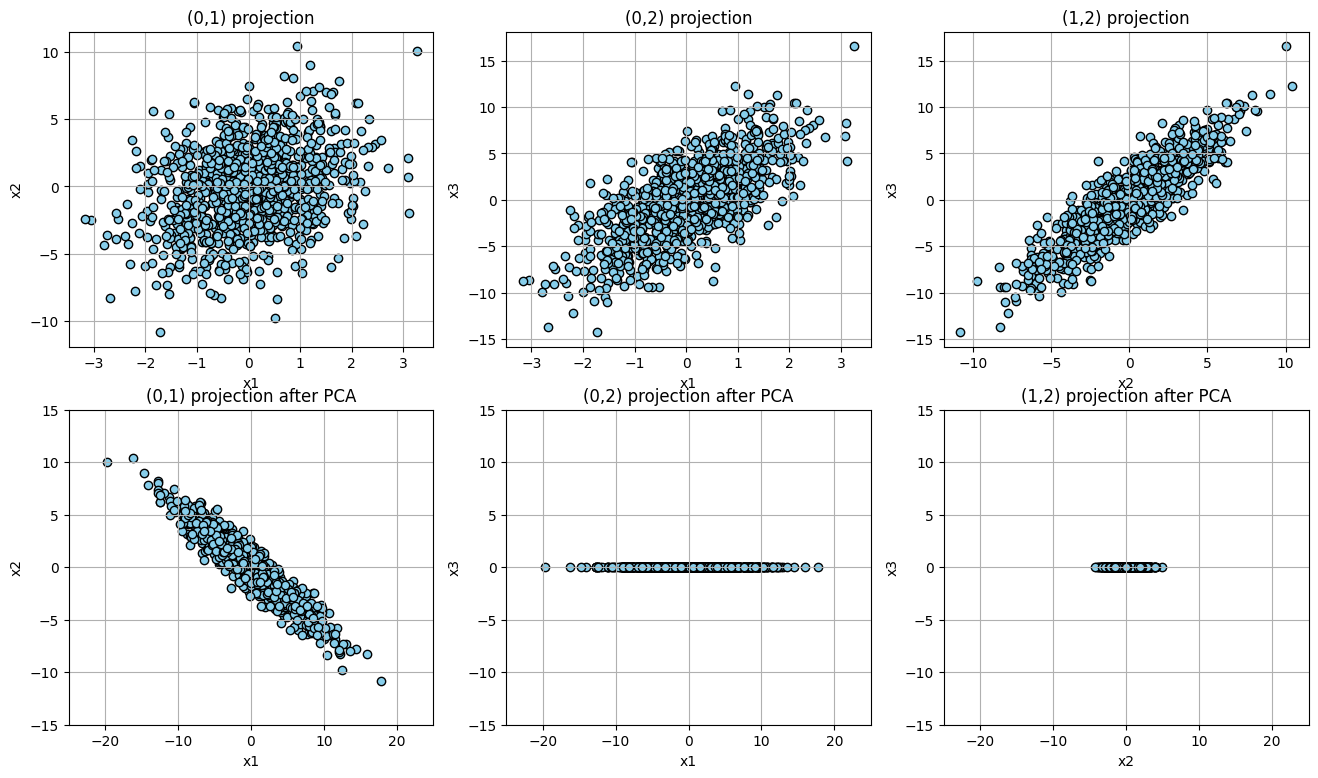

In [77]:
import numpy as np
import numpy.random as npr
import scipy.linalg as la
import matplotlib.pyplot as plt

npr.seed(400)

n = 1000
x1 = npr.normal(0,1,n)
x2 = x1 + npr.normal(0,3,n)
x3 = 2*x1 + x2
x = np.array([x1, x2, x3])
print(x)
cov = np.cov(x)
print(cov)
l , V = la.eig(cov)
print("Eigenvalues: " , l)
print("Eigenvectors: ", V)

#print(np.real_if_close(l))
means = np.mean(x, axis = 1, keepdims = True)
cent_data = x - means
U, spectrum, Vt = np.linalg.svd(cent_data)
print("Eigenvalues with svd: " , spectrum**2/(n-1))
print("Eigenvectors with svd: ", U)
print(U.T)

Lambda = np.diag(spectrum**2/(n-1))
print(Lambda)
print ("Lambda trace():", Lambda.trace())
print (Lambda[0,0]/Lambda.trace())
print (Lambda[1,1]/Lambda.trace())
Lambda[2,2] = 0
print(Lambda.trace())
print (Lambda[0,0]/Lambda.trace())

fig, ax = plt.subplots(nrows = 2, ncols = 3, figsize = (16,9))
ax[0][0].scatter(x = x[0, :], y = x[1,:], color = 'skyblue', edgecolor = 'black')
ax[0][0].grid(True)
ax[0][0].set_xlabel('x1')
ax[0][0].set_ylabel('x2')
ax[0][0].set_title('(0,1) projection')

ax[0][1].scatter(x = x[0, :], y = x[2,:], color = 'skyblue', edgecolor = 'black')
ax[0][1].grid(True)
ax[0][1].set_xlabel('x1')
ax[0][1].set_ylabel('x3')
ax[0][1].set_title('(0,2) projection')

ax[0][2].scatter(x = x[1, :], y = x[2,:], color = 'skyblue', edgecolor = 'black')
ax[0][2].grid(True)
ax[0][2].set_xlabel('x2')
ax[0][2].set_ylabel('x3')
ax[0][2].set_title('(1,2) projection')

print(cent_data)
xp = np.dot(U.T, cent_data)
print(xp)

ax[1][0].scatter(x = xp[0, :], y = x[1,:], color = 'skyblue', edgecolor = 'black')
ax[1][0].grid(True)
ax[1][0].set_xlabel('x1')
ax[1][0].set_ylabel('x2')
ax[1][0].set_title('(0,1) projection after PCA')
ax[1][0].set_xlim(-25, 25)
ax[1][0].set_ylim(-15, 15)

ax[1][1].scatter(x = xp[0, :], y = xp[2,:], color = 'skyblue', edgecolor = 'black')
ax[1][1].grid(True)
ax[1][1].set_xlabel('x1')
ax[1][1].set_ylabel('x3')
ax[1][1].set_title('(0,2) projection after PCA')
ax[1][1].set_xlim(-25, 25)
ax[1][1].set_ylim(-15, 15)

ax[1][2].scatter(x = xp[1, :], y = xp[2,:], color = 'skyblue', edgecolor = 'black')
ax[1][2].grid(True)
ax[1][2].set_xlabel('x2')
ax[1][2].set_ylabel('x3')
ax[1][2].set_title('(1,2) projection after PCA')
ax[1][2].set_xlim(-25, 25)
ax[1][2].set_ylim(-15, 15)

2\. **PCA on a nD dataset**

Start from the dataset you have genereted in the previous exercise and add uncorrelated random noise. Such noise should be represented by other 10 uncorrelated variables normal distributed, with standar deviation much smaller (say, a factor 50) than those used to generate the $x_1$ and $x_2$.

Repeat the PCA procedure and compare the results with what you obtained before

,x1,x2,x3,0,1,2,3,4,5,6,7,8,9
0,-1.240970,2.171501,-0.310438,-0.021713,-0.014977,-0.035484,-0.009012,-0.009426,0.006375,0.004538,0.022357,-0.006458,0.022631
1,-0.312947,0.698524,0.072631,0.019947,0.011352,-0.024028,0.012192,0.021681,0.030222,-0.047971,-0.000115,0.010023,-0.006430
2,-0.848947,1.255914,-0.441980,0.005660,0.014363,0.021925,0.023475,-0.007584,-0.022733,-0.008957,0.030368,0.002719,0.007843
3,2.377953,3.884484,8.640389,-0.030126,-0.019988,0.017221,0.017436,-0.007245,0.012849,0.003948,-0.014671,0.007940,-0.010840
4,0.657501,6.836440,8.151441,-0.011572,0.009498,-0.030407,0.038094,-0.013621,-0.022558,0.012547,-0.034816,-0.005340,-0.030268
...,...,...,...,...,...,...,...,...,...,...,...,...,...
995,-0.057424,-2.693977,-2.808826,0.012695,0.016914,-0.001507,-0.018159,-0.022445,-0.000430,0.009221,0.015171,0.010125,-0.011958
996,-0.394731,3.802701,3.013238,0.021398,-0.022398,-0.018924,-0.036361,-0.028373,0.034196,-0.028349,0.011649,0.022690,-0.027959
997,-0.370076,-7.533463,-8.273614,-0.018187,-0.007186,0.040809,-0.002455,-0.037194,0.026498,0.017502,-0.032141,-0.013080,-0.009445
998,-0.491447,-1.573970,-2.556865,0.009405,-0.032194,0.020318,0.035890,0.018276,-0.009015,0.009070,-0.007815,0.000318,0.011639


x1    0.061484
x2    0.124939
x3    0.247908
0    -0.000791
1     0.000168
2     0.000207
3     0.001330
4     0.001195
5    -0.000369
6     0.000580
7    -0.000758
8     0.000694
9    -0.000313
Name: mean, dtype: float64
           x1        x2        x3         0         1         2         3  \
0   -1.302454  2.046562 -0.558346 -0.020921 -0.015144 -0.035692 -0.010342   
1   -0.374431  0.573585 -0.175277  0.020738  0.011184 -0.024235  0.010862   
2   -0.910431  1.130975 -0.689888  0.006451  0.014195  0.021718  0.022145   
3    2.316468  3.759545  8.392481 -0.029335 -0.020155  0.017014  0.016107   
4    0.596016  6.711501  7.903533 -0.010781  0.009330 -0.030614  0.036765   
..        ...       ...       ...       ...       ...       ...       ...   
995 -0.118909 -2.818916 -3.056734  0.013487  0.016746 -0.001714 -0.019489   
996 -0.456216  3.677762  2.765330  0.022190 -0.022566 -0.019131 -0.037690   
997 -0.431560 -7.658402 -8.521522 -0.017395 -0.007354  0.040602 -0.003784   
998 -0.5

(-20.0, 20.0)

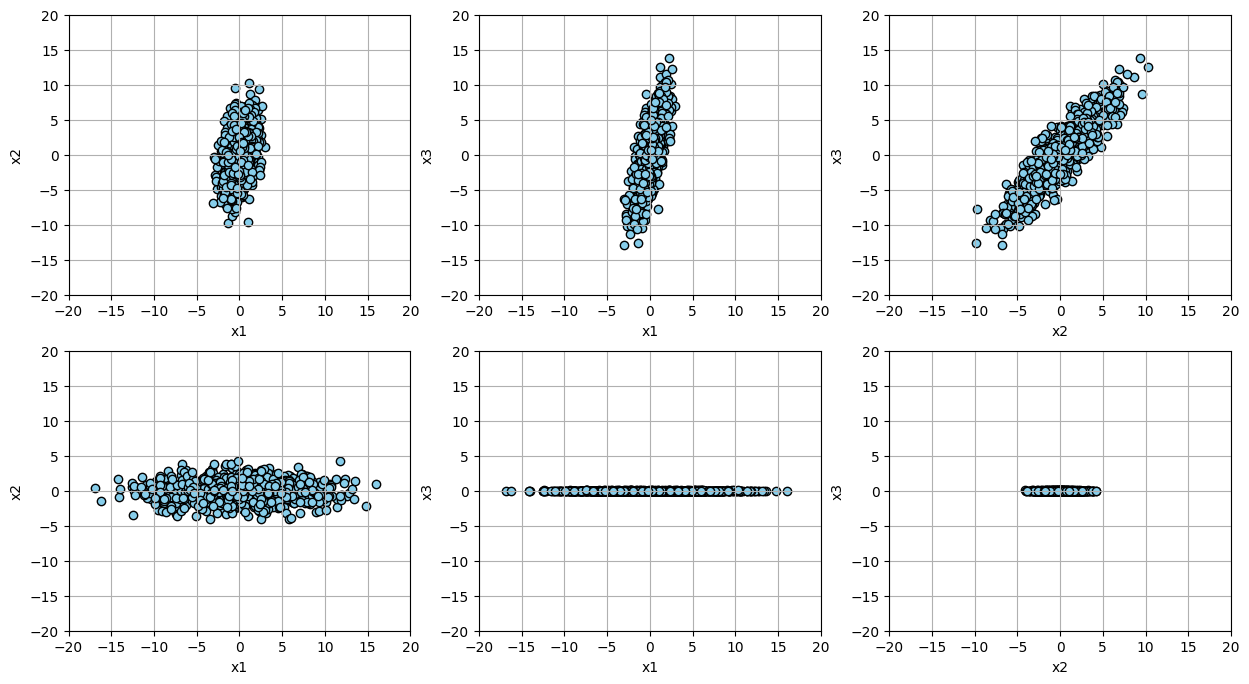

In [117]:
import scipy.linalg as la
npr.seed(123)

noise = [npr.normal(0, 1/50,1000) for i in range(10)]
df = pd.DataFrame({ })
df['x1'] = npr.normal(0, 1, 1000)
df['x2'] = df['x1'] + npr.normal(0, 3, 1000)
df['x3'] = 2*df['x1'] + df['x2']
for i in range(10):
    df[f'{i}'] = noise[i]
display(df)

means = df.describe().iloc[1, :]
print(means)
df0 = df - means
print(df0)

U, spectrum, Vt = la.svd(df0.T)
print('eigenvalues: ', spectrum**2/999 )
print('eigenvectors: ', U)

xp = np.dot(U.T, df0.T)
print(xp)
gridsize = (2,3)
fig = plt.figure(figsize=(15, 8))
ax1 = plt.subplot2grid(gridsize, (0,0), colspan=1, rowspan=1, )
ax1.scatter(df0['x1'], df0['x2'], marker = 'o', c = 'skyblue', edgecolor = 'black')
ax1.grid()
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.set_xlim(-20,20)
ax1.set_ylim(-20,20)

ax2 = plt.subplot2grid(gridsize, (0,1), rowspan=1, colspan=1)
ax2.scatter(df0['x1'], df0['x3'], marker = 'o', c = 'skyblue', edgecolor = 'black')
ax2.grid()
ax2.set_xlabel('x1')
ax2.set_ylabel('x3')
ax2.set_xlim(-20,20)
ax2.set_ylim(-20,20)

ax3 = plt.subplot2grid(gridsize, (0,2), rowspan=1, colspan=1)
ax3.scatter(df0['x2'], df0['x3'], marker = 'o', c = 'skyblue', edgecolor = 'black')
ax3.grid()
ax3.set_xlabel('x2')
ax3.set_ylabel('x3')
ax3.set_xlim(-20,20)
ax3.set_ylim(-20,20)

ax4 = plt.subplot2grid(gridsize, (1,0), rowspan=1, colspan=1)
ax4.scatter(xp[0, :], xp[1, :], marker = 'o', c = 'skyblue', edgecolor = 'black')
ax4.grid()
ax4.set_xlabel('x1')
ax4.set_ylabel('x2')
ax4.set_xlim(-20,20)
ax4.set_ylim(-20,20)

ax5 = plt.subplot2grid(gridsize, (1,1), rowspan=1, colspan=1)
ax5.scatter(xp[0, :], xp[2,:], marker = 'o', c = 'skyblue', edgecolor = 'black')
ax5.grid()
ax5.set_xlabel('x1')
ax5.set_ylabel('x3')
ax5.set_xlim(-20,20)
ax5.set_ylim(-20,20)

ax6 = plt.subplot2grid(gridsize, (1,2), rowspan=1, colspan=1)
ax6.scatter(xp[1, :], xp[2, :], marker = 'o', c = 'skyblue', edgecolor = 'black')
ax6.grid()
ax6.set_xlabel('x2')
ax6.set_ylabel('x3')
ax6.set_xlim(-20,20)
ax6.set_ylim(-20,20)

Eigenvalues with svd:  [2.63565029e+01 1.86454884e+00 4.49655872e-04 4.36776358e-04
 4.30016319e-04 4.21594163e-04 4.09589970e-04 3.77828908e-04
 3.71107561e-04 3.65131923e-04 3.53783247e-04 3.37399620e-04
 5.72149399e-32]
Eigenvectors with svd:  [[-1.16852023e-01  5.65400911e-01 -2.73708049e-04 -5.87474554e-04
  -1.68751064e-05 -2.25534514e-04 -2.44275637e-05 -2.41991017e-04
  -5.90419985e-06 -1.11843192e-04 -4.52204195e-04  5.60480457e-06
  -8.16496581e-01]
 [-5.75620584e-01 -7.08514603e-01  1.89386283e-04  8.77867321e-04
   7.26191304e-05  1.69176060e-04 -5.79779138e-05  2.91246770e-04
   1.17126834e-04  1.02407582e-05  6.25113181e-04 -3.92527666e-05
  -4.08248290e-01]
 [-8.09324629e-01  4.22287220e-01 -3.58029815e-04 -2.97081786e-04
   3.88689176e-05 -2.81892967e-04 -1.06833041e-04 -1.92735264e-04
   1.05318434e-04 -2.13445626e-04 -2.79295210e-04 -2.80431574e-05
   4.08248290e-01]
 [-1.30810936e-04 -3.69639194e-04  1.02103991e-01 -5.74732431e-01
   3.67403170e-01  1.74088493e-01  1

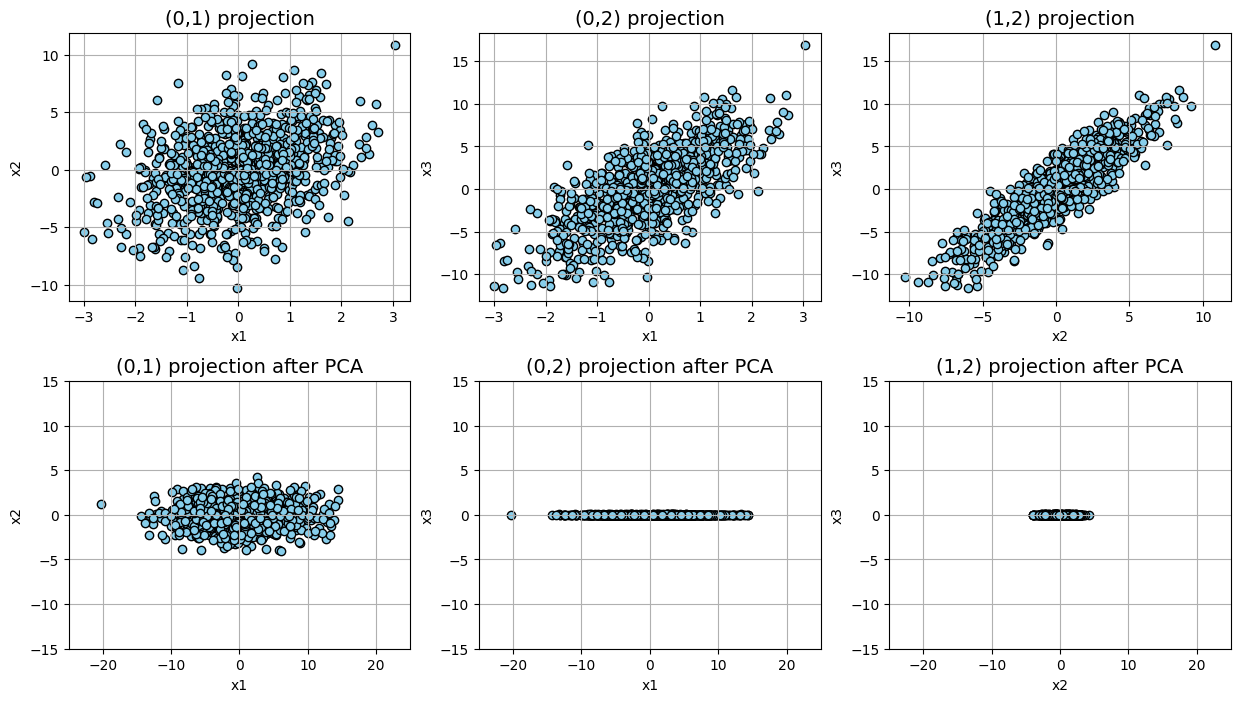

In [101]:
npr.seed(400)
n = 1000
noise = np.array([npr.normal(0,1/50, 1000) for i in range(10)])
x1 = npr.normal(0,1,n)
x2 = x1 + npr.normal(0,3,n)
x3 = 2*x1 + x2
x = np.array([x1, x2, x3])
data = np.concatenate((x, noise))

means = np.mean(data, axis = 1, keepdims = True)
cent_data = data - means
U, spectrum, Vt = np.linalg.svd(cent_data)
print("Eigenvalues with svd: " , spectrum**2/(n-1))
print("Eigenvectors with svd: ", U)

gridsize = (2, 3) #3 righe 2 colonne 
fig = plt.figure(figsize=(15, 8))

ax1 = plt.subplot2grid(gridsize, (0, 0), colspan=1, rowspan=1) 
ax1.scatter(x=data[0, :], y=data[1, :], c='skyblue', edgecolor = 'black') 
ax1.set_title('(0,1) projection', fontsize=14)
ax1.set_xlabel('x1')
ax1.set_ylabel('x2')
ax1.grid(True)

ax2 = plt.subplot2grid(gridsize, (0, 1), colspan=1, rowspan=1) 
ax2.scatter(x=data[0, :], y=data[2, :], c='skyblue', edgecolor = 'black') 
ax2.set_title('(0,2) projection', fontsize=14)
ax2.set_xlabel('x1')
ax2.set_ylabel('x3')
ax2.grid(True)

ax3 = plt.subplot2grid(gridsize, (0, 2), colspan=1, rowspan=1) 
ax3.scatter(x=data[1, :], y=data[2, :], c='skyblue', edgecolor = 'black') 
ax3.set_title('(1,2) projection', fontsize=14)
ax3.set_xlabel('x2')
ax3.set_ylabel('x3')
ax3.grid(True)

datap= np.dot(U.T, cent_data)
print(xp)

ax4 = plt.subplot2grid(gridsize, (1, 0), colspan=1, rowspan=1) 
ax4.scatter(x=datap[0,:], y=datap[1,:], c='skyblue', edgecolor = 'black') 
ax4.set_title('(0,1) projection after PCA', fontsize=14)
ax4.set_xlabel('x1')
ax4.set_ylabel('x2')
ax4.set_xlim(-25,25)
ax4.set_ylim(-15,15)
ax4.grid(True)

ax5 = plt.subplot2grid(gridsize, (1, 1), colspan=1, rowspan=1) 
ax5.scatter(x=datap[0,:], y=datap[2,:], c='skyblue', edgecolor = 'black') 
ax5.set_title('(0,2) projection after PCA', fontsize=14)
ax5.set_xlabel('x1')
ax5.set_ylabel('x3')
ax5.set_xlim(-25,25)
ax5.set_ylim(-15,15)
ax5.grid(True)

ax6 = plt.subplot2grid(gridsize, (1, 2), colspan=1, rowspan=1) 
ax6.scatter(x=datap[1,:], y=datap[2,:], c='skyblue', edgecolor = 'black') 
ax6.set_title('(1,2) projection after PCA', fontsize=14)
ax6.set_xlabel('x2')
ax6.set_ylabel('x3')
ax6.set_xlim(-25,25)
ax6.set_ylim(-15,15)
ax6.grid(True)
plt.subplots_adjust(hspace=0.3)

# PCA will still recognize the principal variance components => the principal components will remain almost unchanged after adding noise at slow variance!

3 \. **Looking at an oscillating spring** (optional)

Imagine you have $n$ cameras looking at a spring oscillating along the $x$ axis. Each  camera record the motion of the spring looking at it along a given direction defined by the pair $(\theta_i, \phi_i)$, the angles in spherical coordinates. 

Start from the simulation of the records (say ${\cal O}(1000)$) of the spring's motion along the x axis, assuming a little random noise affects the measurements along the $y$. Rotate such dataset to emulate the records of each camera.

Perform a Principal Component Analysis on the thus obtained dataset, aiming at finding the only one coordinate that really matters.


4\. **PCA on the MAGIC dataset** (optional)

Perform a PCA on the magic04.data dataset

In [ ]:
# get the dataset and its description on the proper data directory
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.data -P ~/data/
!wget https://archive.ics.uci.edu/ml/machine-learning-databases/magic/magic04.names -P ~/data/ 